In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../Mamoth Modules")
sys.path.insert(0, "../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [3]:
shape_file = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'data/{NUTS0}_{NUTS2}_WNV_Timeline_2010-2021.csv', encoding=enc)

In [5]:
shape_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.662866,22.635299,14407.0,14025.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-01,39.650181,22.650104,0.000441,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.662866,22.635299,14295.0,13485.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-16,39.650181,22.650104,18.932700,2010-01-09,2010-01-02,2010-01-09,2010-01-02,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.752697,22.707165,14367.0,NaN,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.752697,22.707165,14093.0,13628.0,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-16,39.750182,22.750104,50.056047,2010-01-09,2010-01-02,2010-01-09,2010-01-02,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,2009-12-07,39.788630,22.729622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.788630,22.729622,14227.0,NaN,39.788630,22.729622,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [7]:
shape_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
process_greek(shape_file, 'lau1')
process_greek(shape_file, 'nuts2')

In [9]:
shape_file = shape_file.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
shape_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [11]:
shape_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14407.0,14025.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,0.000441,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14295.0,13485.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,18.932700,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,NaN,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,0.030362,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14093.0,13628.0,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,50.056047,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14227.0,NaN,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,0.030362,0.030362,0.030362


In [12]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αγιας,θεσσαλιας,2010-06-01,0
1,αγιας,θεσσαλιας,2010-06-16,0
2,αγιας,θεσσαλιας,2010-07-01,0
3,αγιας,θεσσαλιας,2010-07-16,1
4,αγιας,θεσσαλιας,2010-08-01,0


In [13]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

list1 = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
list2 = shape_file["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")


['ρηγα φεραιου']

Length: 1


In [14]:
shape_file['lau1'] = shape_file['lau1'].apply(lambda x : x.replace('ρηγα φερραιου','ρηγα φεραιου'))

In [15]:
## Check again

list1 = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
list2 = shape_file["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [16]:
merged = shape_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [17]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14407.0,14025.0,14216.714286,13830.000000,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,0.000441,0.000441,0.000441,NaN
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14295.0,13485.0,14216.714286,13830.000000,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,18.932700,13.140626,18.916778,NaN
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,NaN,14225.500000,13773.400000,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,0.030362,0.030362,0.030362,NaN
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14093.0,13628.0,14225.500000,13773.400000,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,50.056047,33.498169,49.542448,NaN
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14227.0,NaN,13896.166667,13803.750000,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,0.030362,0.030362,0.030362,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36283,φαρσαλων,θεσσαλιας,22.45598,39.35493,2021-12-16,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.538462,13680.875000,14408.866667,13900.533333,14530.315789,13798.153846,14780.928571,14022.058824,1398.456442,53.314030,115.708345,NaN
36284,φαρσαλων,θεσσαλιας,22.45598,39.39086,2021-12-01,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14156.583333,13716.000000,14394.461538,13892.500000,14520.375000,13800.666667,14735.133333,14050.764706,1282.748097,153.097007,209.865133,NaN
36285,φαρσαλων,θεσσαλιας,22.45598,39.39086,2021-12-16,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14156.583333,13716.000000,14394.461538,13892.500000,14520.375000,13800.666667,14735.133333,14050.764706,1398.456442,53.314030,115.708345,NaN
36286,φαρσαλων,θεσσαλιας,22.59495,39.30103,2021-12-01,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14128.923077,13653.857143,14453.571429,13917.466667,14497.476190,13807.333333,14866.071429,13996.133333,1269.494836,158.110106,224.962835,NaN


In [20]:
merged = fillna(merged,{'case': 0})

In [21]:
merged['case'].value_counts()

0.0    35872
1.0      233
2.0      147
3.0       34
7.0        2
Name: case, dtype: int64

In [22]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [23]:
dataset = grouped.mean()

In [24]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αγιας,θεσσαλιας,22.750267,39.710970,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0.0
1,2010-01-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0.0
2,2010-01-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0.0
4,2010-01-01,βολου,θεσσαλιας,22.883800,39.351977,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.553160,39.852112,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0.0
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0.0
7197,2021-12-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2021.0,12.0,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0.0
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0.0


In [25]:
dataset = dataset.astype({'case': 'int'})

In [26]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [27]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [28]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [29]:
with open(f'data/{NUTS0}_WNV_{NUTS2}_LAU1_mapping.json', 'w', encoding=enc) as file:
     json.dump(lau1_map,file,sort_keys=True, indent=4, ensure_ascii=False)

In [30]:
dataset["lau1_id"] = dataset["lau1"].map(lau1_map)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [31]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0,1,53,45.76610,22,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
1,2010-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0,1,53,45.23937,9,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
2,2010-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0,1,53,46.11198,24,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
3,2010-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0,1,53,44.69433,0,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
4,2010-01-01,βολου,θεσσαλιας,22.88380,39.35198,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0,1,53,45.52194,14,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0,16,50,45.79122,23,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0,16,50,45.23352,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7197,2021-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2021,12,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0,16,50,45.66746,18,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0,16,50,45.31404,11,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742


<AxesSubplot:>

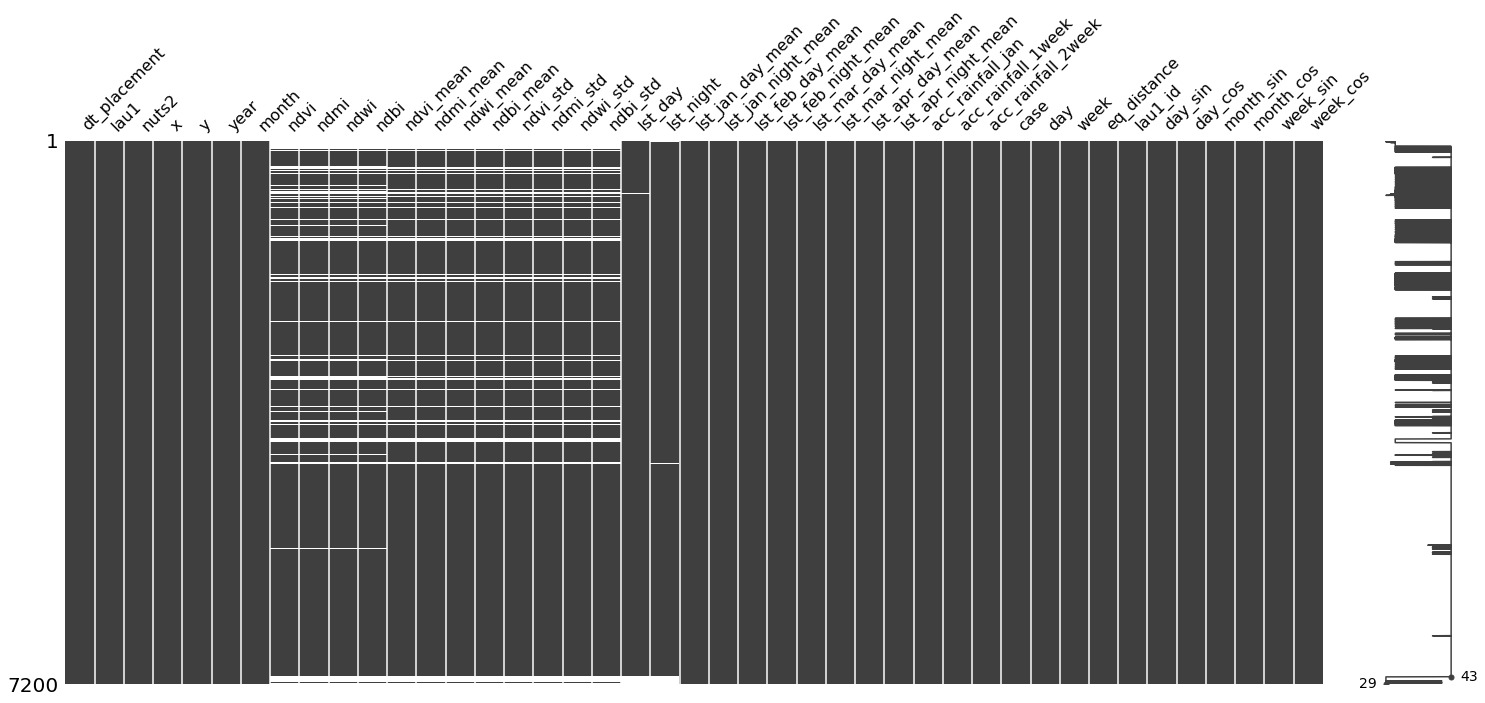

In [32]:
missingno.matrix(dataset)

In [33]:
df_demographics = pd.read_csv(f'data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [34]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [35]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [36]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [37]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [38]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

['καλαμπακας', 'λαρισαιων', 'φαρκαδονας']

Length: 3


In [39]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [40]:
list1 = dataset["lau1"].drop_duplicates().sort_values().tolist()
list2 = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
list3 = []

for element in list1:
    if element not in list2:
        list3.append(element)
        

print(f"{list3}\n\nLength: {len(list3)}")

[]

Length: 0


In [41]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

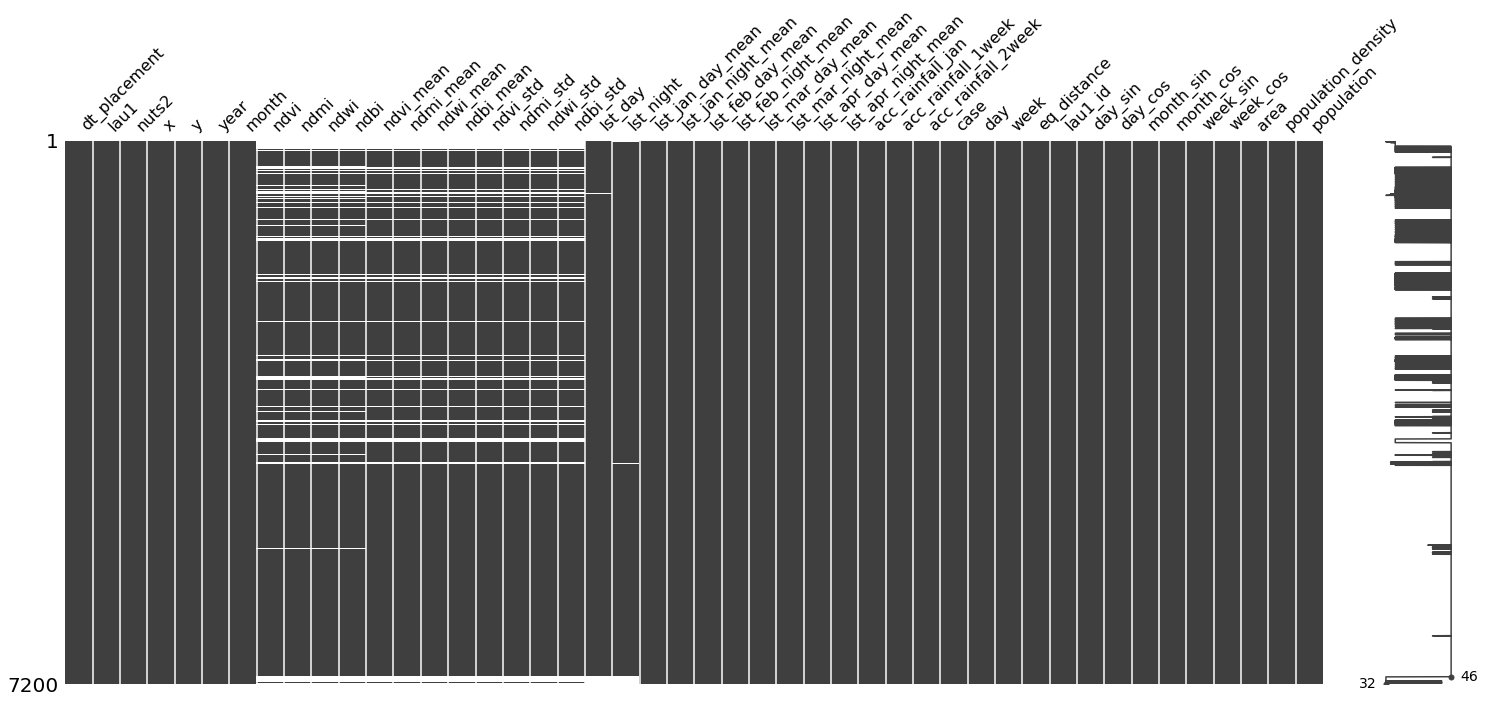

In [42]:
missingno.matrix(dataset)

In [43]:
missing = describe_dataframe(dataset)

In [44]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2010-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0,1,53,45.76610,22,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,661.8,17.3,10705.00
1,2010-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0,1,53,45.23937,9,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,905.4,20.6,16004.00
2,2010-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0,1,53,46.11198,24,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,129.6,21.2,3153.00
3,2010-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0,1,53,44.69433,0,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,372.9,9.3,3515.00
4,2010-01-01,βολου,θεσσαλιας,22.88380,39.35198,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0,1,53,45.52194,14,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0,16,50,45.79122,23,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,576.7,23.8,11.99
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0,16,50,45.23352,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,607.6,133.9,78508.00
7197,2021-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2021,12,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0,16,50,45.66746,18,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,525.3,47.7,22252.00
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0,16,50,45.31404,11,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,368.7,36.3,11348.00


In [45]:
mosquito_data = read_data(f'data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [46]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [47]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [48]:
mosq_columns = mosquito_data_nuts2.columns

In [49]:
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [50]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


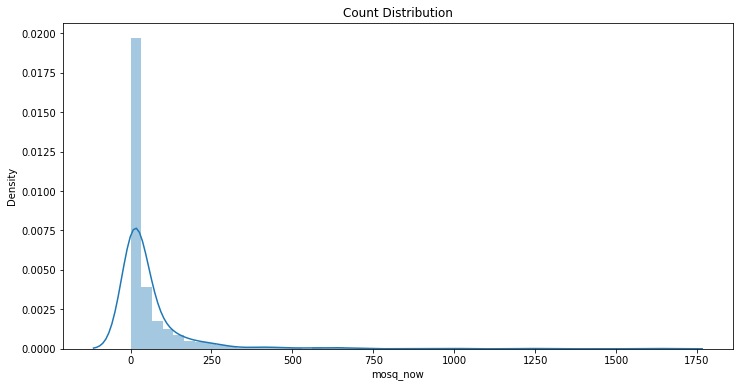

In [51]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [52]:
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.95)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_24264/2570903501.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


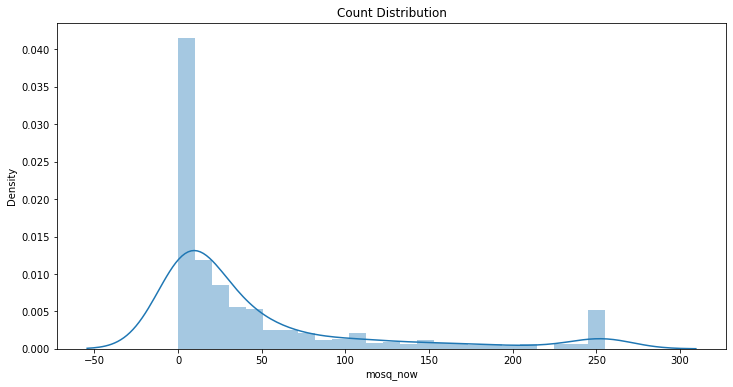

In [53]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

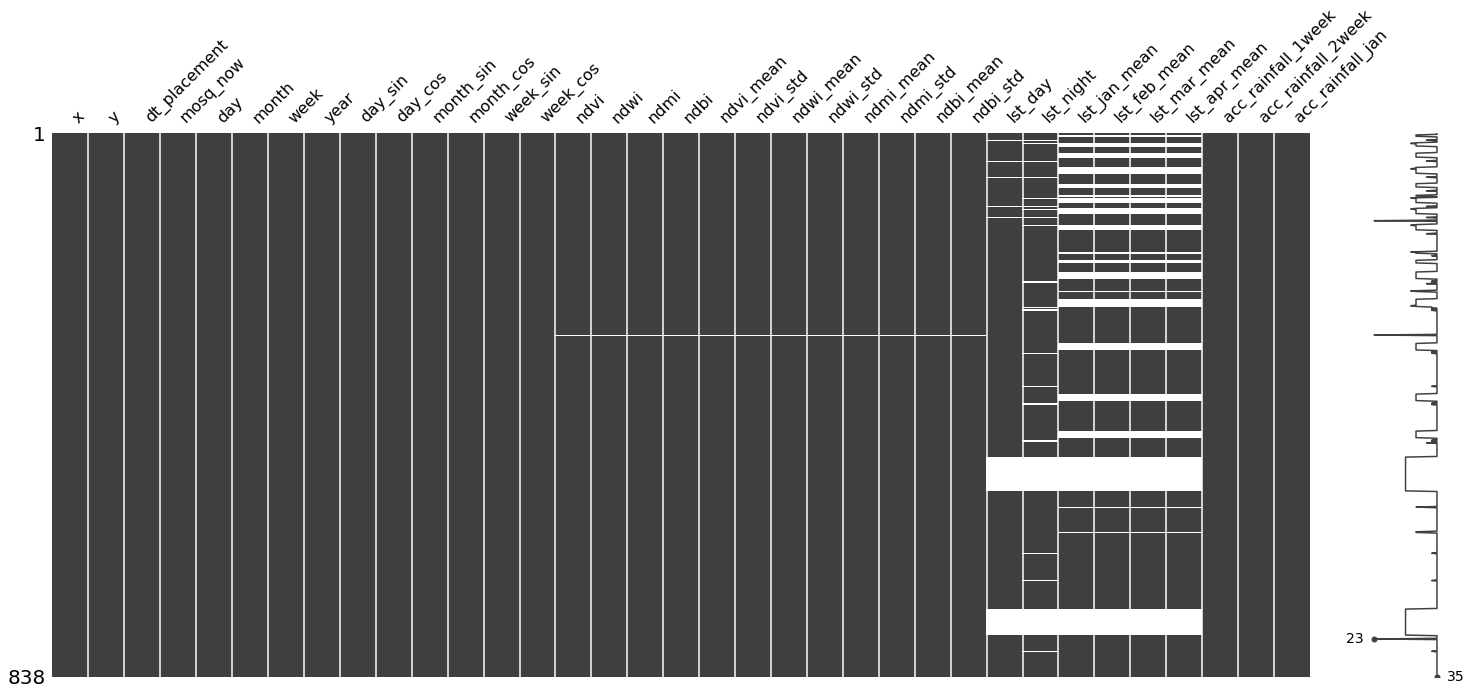

In [54]:
missingno.matrix(mosquito_data_nuts2)

In [55]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [56]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

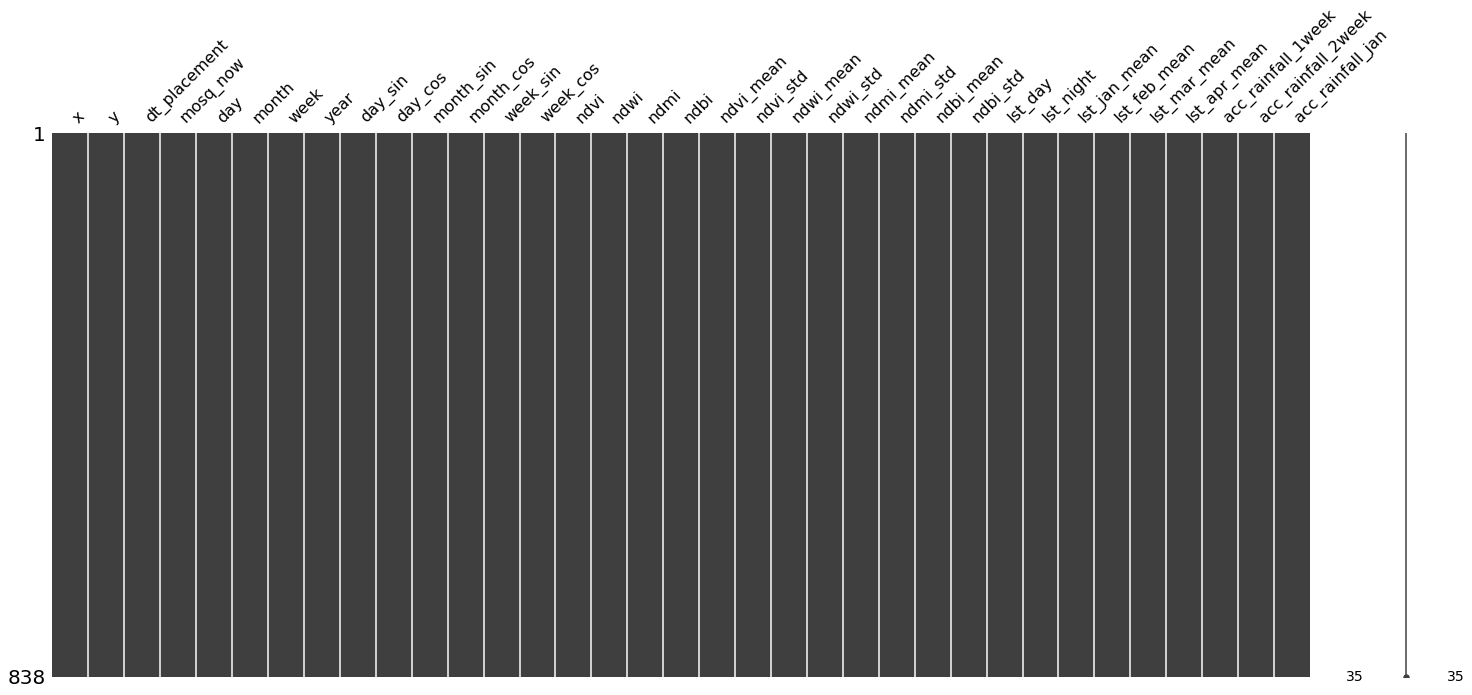

In [57]:
missingno.matrix(mosquito_data_nuts2)

In [58]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [59]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.    16.5  255.15]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [60]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 43.96636 | Val Loss: 30.93489 | Train Acc: 4.669| Val Acc: 3.830
Epoch 002: | Train Loss: 39.58124 | Val Loss: 29.24532 | Train Acc: 4.024| Val Acc: 3.501
Epoch 003: | Train Loss: 37.19172 | Val Loss: 27.67646 | Train Acc: 3.465| Val Acc: 3.238
Epoch 004: | Train Loss: 35.46292 | Val Loss: 26.65747 | Train Acc: 3.229| Val Acc: 3.064
Epoch 005: | Train Loss: 34.66358 | Val Loss: 25.95929 | Train Acc: 3.041| Val Acc: 2.870
Epoch 006: | Train Loss: 34.23430 | Val Loss: 24.45163 | Train Acc: 2.939| Val Acc: 2.388
Epoch 007: | Train Loss: 33.61767 | Val Loss: 23.33625 | Train Acc: 2.909| Val Acc: 2.085
Epoch 008: | Train Loss: 33.88531 | Val Loss: 23.29483 | Train Acc: 2.891| Val Acc: 1.723
Epoch 009: | Train Loss: 33.33784 | Val Loss: 23.09416 | Train Acc: 2.820| Val Acc: 1.688
Epoch 010: | Train Loss: 32.99423 | Val Loss: 22.83546 | Train Acc: 2.807| Val Acc: 2.001
Epoch 011: | Train Loss: 32.76726 | Val Loss: 22.66622 | Train Acc: 2.757| Val Acc: 1.832
Epoch 012:

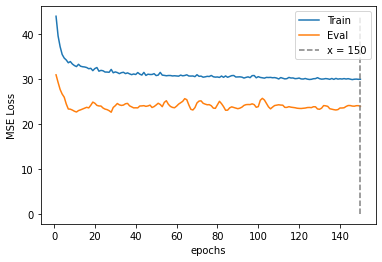

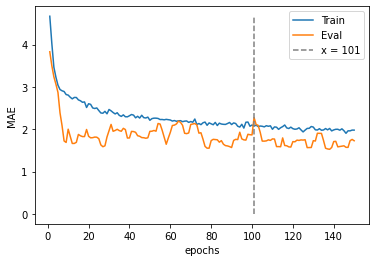

In [61]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [62]:
metrics(train, test, threshold=30)

MAE on train set:  27.3771472149519
min prediction: 1
max prediction: 242

MAE on test set:  28.8148851746625
Error ⩽ 30: 73.28 %
min prediction: 1
max prediction: 253


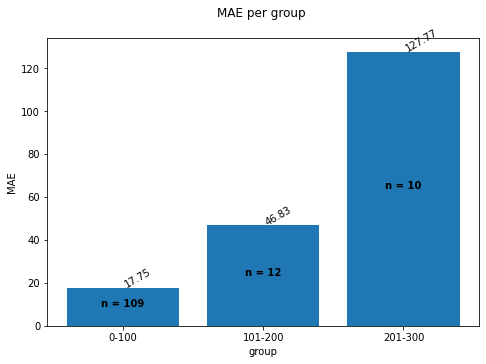

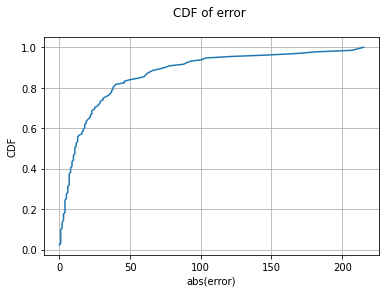

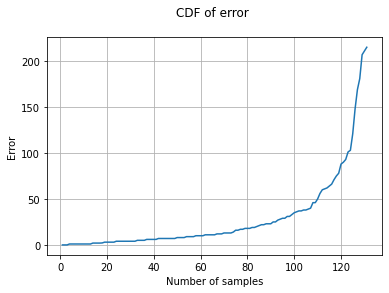

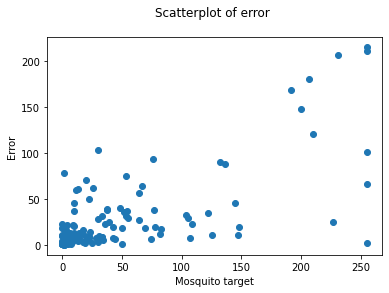

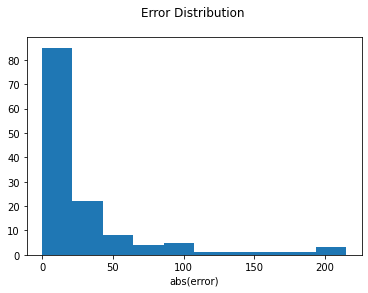

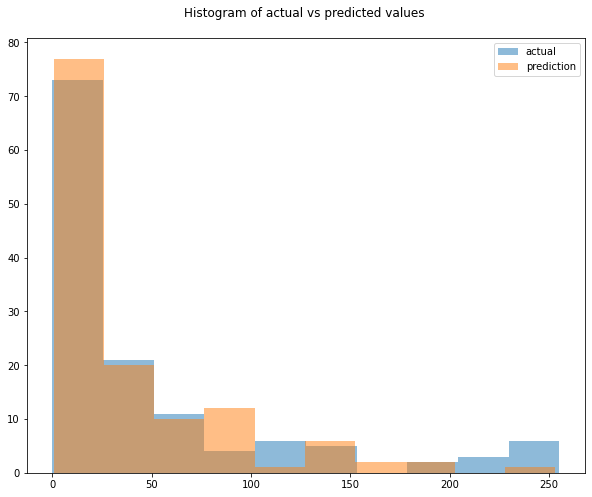

In [63]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.99660 | Val Loss: 0.10306 | Train Acc: 2.457| Val Acc: 0.542
Epoch 002: | Train Loss: 33.64534 | Val Loss: 0.11306 | Train Acc: 2.354| Val Acc: 0.542
Epoch 003: | Train Loss: 32.83337 | Val Loss: 0.33271 | Train Acc: 2.272| Val Acc: 0.542
Epoch 004: | Train Loss: 32.77186 | Val Loss: 0.21581 | Train Acc: 2.236| Val Acc: 0.542
Epoch 005: | Train Loss: 33.01480 | Val Loss: 0.19429 | Train Acc: 2.322| Val Acc: 0.542
Epoch 006: | Train Loss: 32.78443 | Val Loss: 0.23907 | Train Acc: 2.277| Val Acc: 0.542
Epoch 007: | Train Loss: 32.59133 | Val Loss: 0.35248 | Train Acc: 2.235| Val Acc: 0.542
Epoch 008: | Train Loss: 32.85849 | Val Loss: 0.07152 | Train Acc: 2.204| Val Acc: 0.542
Epoch 009: | Train Loss: 32.52951 | Val Loss: 0.06399 | Train Acc: 2.207| Val Acc: 0.458
Epoch 010: | Train Loss: 32.32143 | Val Loss: 0.05171 | Train Acc: 2.185| Val Acc: 0.458
Epoch 011: | Train Loss: 32.46944 | Val Loss: 0.13612 | Train Acc: 2.160| Val Acc: 0.542
Epoch 012: | Train Lo

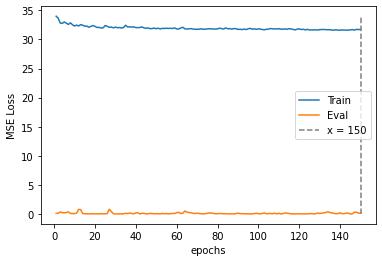

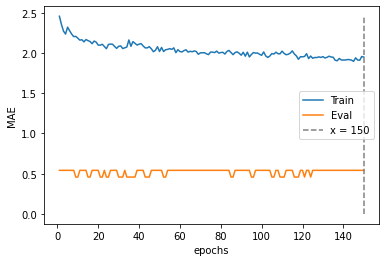

In [64]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [65]:
# mamoth_columns = ['x','y','dt_placement','day','month','week','year', 
#                   'day_sin','day_cos','month_sin','month_cos','week_sin','week_cos',
#                   'ndvi','ndmi','ndwi','ndbi', 'ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean', 
#                   'ndvi_std','ndmi_std','ndwi_std','ndbi_std',
#                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean', 
#                   'acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_jan', 'mosq_now' ]

In [66]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [67]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [68]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [69]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [70]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [71]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

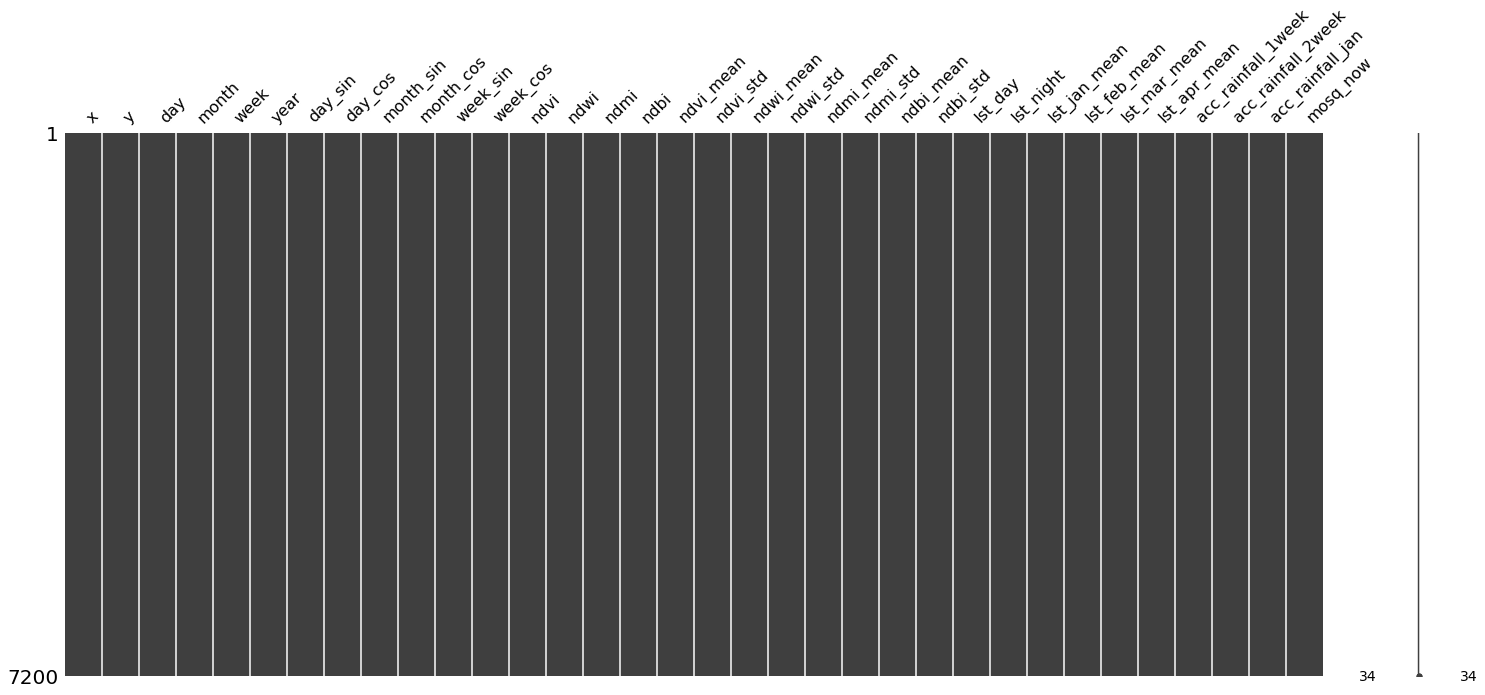

In [72]:
missingno.matrix(dataset_mamoth)

In [73]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [74]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [75]:
predictions = give_predictions(model, dataset_mamoth)

In [76]:
mosqutio_predictions['mosq_pred'] = predictions

In [77]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.75027,39.71097,2010-01-01,4
1,22.69237,39.13639,2010-01-01,1
2,24.07379,39.32896,2010-01-01,1
3,21.43051,39.22138,2010-01-01,1
4,22.88380,39.35198,2010-01-01,1
...,...,...,...,...
7195,22.55316,39.85211,2021-12-16,48
7196,21.79756,39.63506,2021-12-16,48
7197,22.34300,39.82847,2021-12-16,7
7198,22.02056,39.60375,2021-12-16,50


In [78]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x','y','dt_placement'])

In [79]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,lau1_id,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2010-01-01,αγιας,θεσσαλιας,22.75027,39.71097,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327,0,1,53,45.76610,22,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,661.8,17.3,10705.00,4
1,2010-01-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382,0,1,53,45.23937,9,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,905.4,20.6,16004.00,1
2,2010-01-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000,0,1,53,46.11198,24,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,129.6,21.2,3153.00,1
3,2010-01-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201,0,1,53,44.69433,0,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,372.9,9.3,3515.00,1
4,2010-01-01,βολου,θεσσαλιας,22.88380,39.35198,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000,0,1,53,45.52194,14,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,385.6,374.6,138865.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.55316,39.85211,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479,0,16,50,45.79122,23,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,576.7,23.8,11.99,48
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.79756,39.63506,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311,0,16,50,45.23352,8,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,607.6,133.9,78508.00,48
7197,2021-12-16,τυρναβου,θεσσαλιας,22.34300,39.82847,2021,12,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025,0,16,50,45.66746,18,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,525.3,47.7,22252.00,7
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489,0,16,50,45.31404,11,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,368.7,36.3,11348.00,50


<AxesSubplot:>

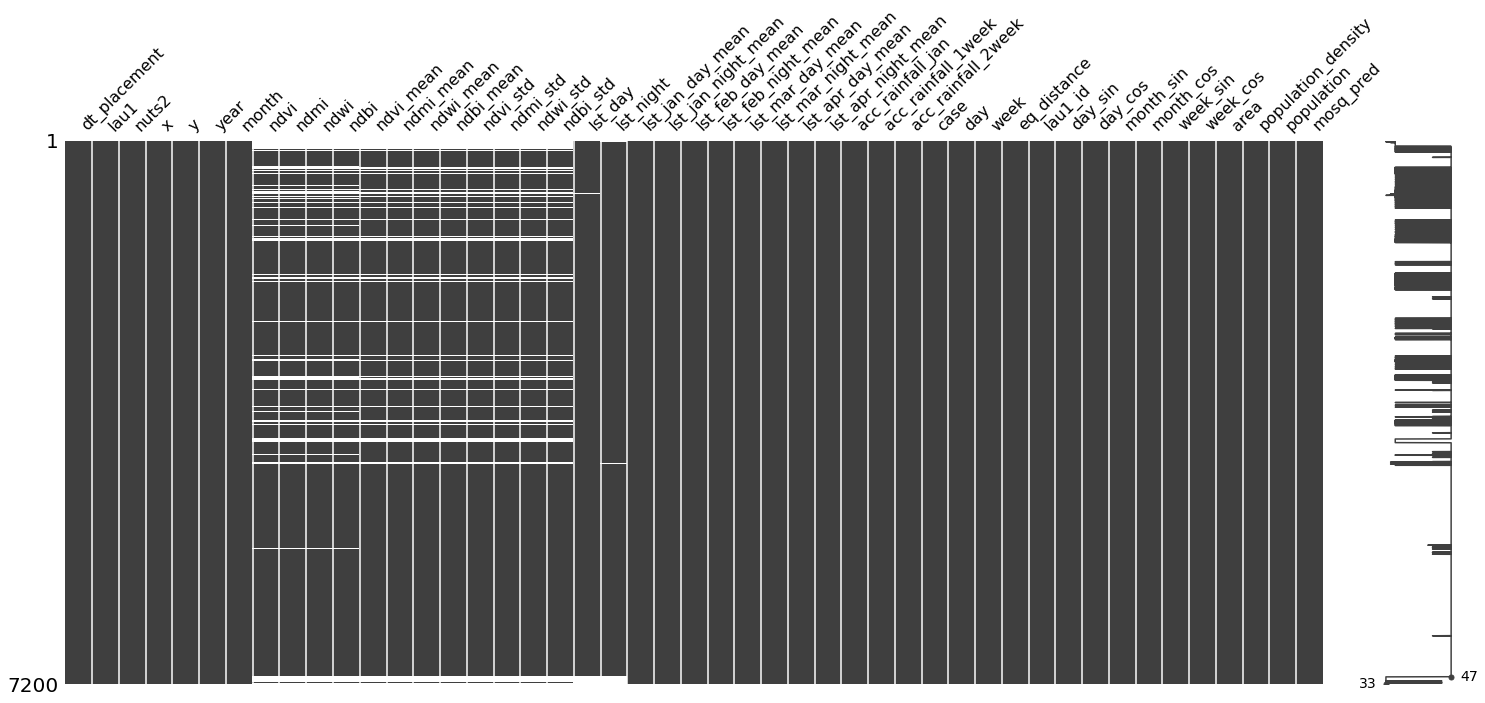

In [80]:
missingno.matrix(dataset)

In [81]:
dataset.reset_index(inplace=True, drop=True)

In [82]:
dataset = calculate_mosq_previous(dataset)

In [83]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

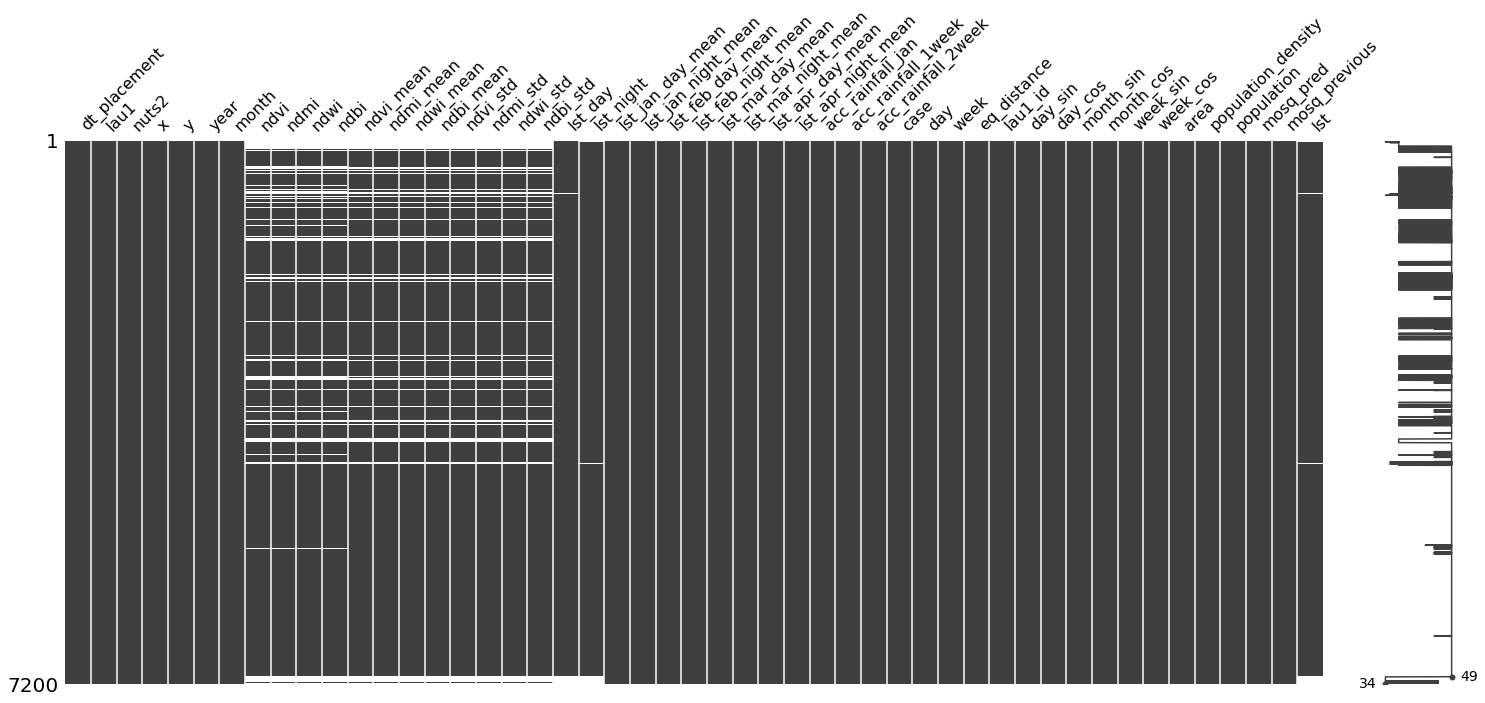

In [84]:
missingno.matrix(dataset)

In [85]:
dataset['case'].value_counts()

0    7127
1      47
2      20
3       5
7       1
Name: case, dtype: int64

In [86]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [87]:
dataset = convert_multiple_cases(dataset)

In [88]:
dataset['case'].value_counts()

0    7127
1     109
Name: case, dtype: int64

In [89]:
cols = dataset.columns

In [90]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'lau1_id', 'day_sin', 'day_cos',
       'month_sin', 'month_cos', 'week_sin', 'week_cos', 'area',
       'population_density', 'population', 'mosq_pred', 'mosq_previous',
       'lst'],
      dtype='object')

In [92]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [94]:
dataset_final = dataset[final_columns].copy()

In [95]:
dataset_final

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.177143,14.644286,7.71,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,0.018327,0.018327,0.018327,4,0,0
1,22.69237,39.13639,2010-01-01,θεσσαλιας,αλμυρου,9,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.237778,17.085556,11.39,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,0.210382,0.210382,0.210382,1,0,0
2,24.07379,39.32896,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.090000,17.810000,12.37,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,0.000000,0.000000,0.000000,1,0,0
3,21.43051,39.22138,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,49.209201,49.209201,49.209201,1,0,0
4,22.88380,39.35198,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.979530,0.5,0.866025,-2.449294e-16,1.000000,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.383333,NaN,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,0.000000,0.000000,0.000000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7231,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,12,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,79,59,1
7232,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,12,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,79,59,1
7233,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,12,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,79,59,1
7234,22.25731,39.56682,2019-07-16,θεσσαλιας,λαρισαιων,12,16,7,29,2019,-0.101168,-0.994869,-0.5,-0.866025,-2.920568e-01,-0.956401,336.0,164381.0,483.9,45.39737,0.29367,-0.124991,-0.338048,0.124991,0.320056,-0.093117,-0.357234,0.093117,0.053954,0.05562,0.040355,0.05562,26.740000,33.020000,20.46,7.386889,-2.422889,15.627500,2.167179,23.428889,6.443099,24.036538,9.583651,73.760626,78.358841,642.383343,79,59,1


In [96]:
dataset_final.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)